## 01. PyTorch Workflow Exercise

1. Create a straight line dataset using the linear regression formula (weight * X + bias).

In [37]:
import torch
import matplotlib.pyplot as plt
from torch import nn

In [38]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [39]:
device

'cuda'

In [ ]:
# Create the data parameters
weight = 0.3
bias = 0.9
# Make X and y using linear regression feature
X = torch.arange(0,1,0.01).unsqueeze(dim = 1)
y = weight * X + bias
print(f"Number of X samples: {len(X)}")
print(f"Number of y samples: {len(y)}")
print(f"First 10 X & y samples:\nX: {X[:10]}\ny: {y[:10]}") 

Number of X samples: 100
Number of y samples: 100
First 10 X & y samples:
X: tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900]])
y: tensor([[0.9000],
        [0.9030],
        [0.9060],
        [0.9090],
        [0.9120],
        [0.9150],
        [0.9180],
        [0.9210],
        [0.9240],
        [0.9270]])


In [47]:

# Split the data into training and testing
train_split = int(len(X) * 0.8)
X_train = X[:train_split]
y_train = y[:train_split]
X_test = X[train_split:]
y_test = y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)

(80, 80, 20, 20)

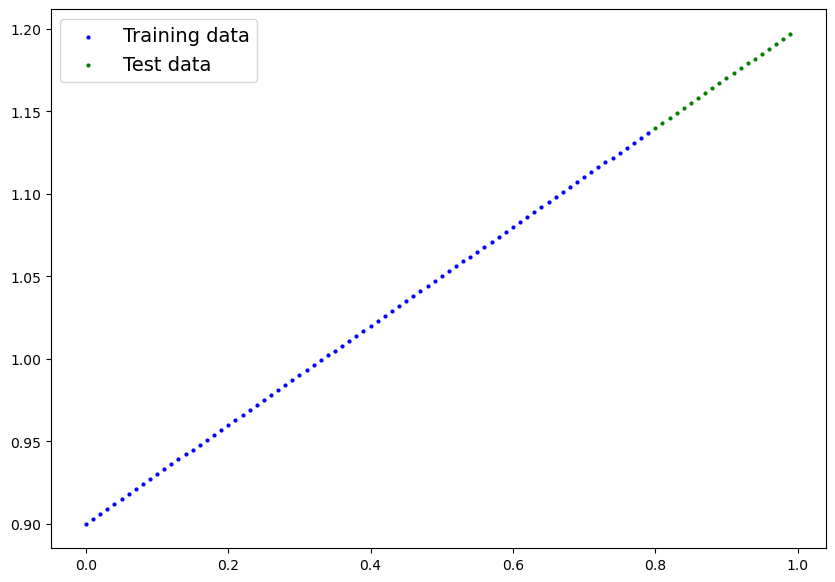

In [42]:

# Plot the training and testing data 
def plot_predictions(train_data = X_train,
                 train_labels = y_train,
                 test_data = X_test,
                 test_labels = y_test,
                 predictions = None):
  plt.figure(figsize = (10,7))
  plt.scatter(train_data,train_labels,c = 'b',s = 4,label = "Training data")
  plt.scatter(test_data,test_labels,c = 'g',s = 4,label = "Test data")

  if predictions is not None:
    plt.scatter(test_data,predictions,c = 'r',s = 4,label = "Predictions")
  plt.legend(prop = {"size" : 14})
plot_predictions()

2. Build a PyTorch model by subclassing nn.Module.  

Inside should be a randomly initialized nn.Parameter() with requires_grad=True, one for weights and one for bias.  

Implement the forward() method to compute the linear regression function you used to create the dataset in 1. 

Once you've constructed the model, make an instance of it and check its state_dict().  

Note: If you'd like to use nn.Linear() instead of nn.Parameter() you can.  

In [48]:
# Create PyTorch linear regression model by subclassing nn.Module
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight = nn.Parameter(data=torch.randn(1, 
                                              requires_grad=True,
                                              dtype=torch.float
                                              ))
    
    self.bias = nn.Parameter(data=torch.randn(1, 
                                              requires_grad=True,
                                              dtype=torch.float
                                              ))

  def forward(self, x):
    return self.weight * x + self.bias
  
torch.manual_seed(42)
model_1 = LinearRegressionModel()
model_1,model_1.state_dict()

(LinearRegressionModel(),
 OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))]))

In [49]:
# Instantiate the model and put it to the target device
model_1.to(device)
list(model_1.parameters())

[Parameter containing:
 tensor([0.3367], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.1288], device='cuda:0', requires_grad=True)]

3. Create a loss function and optimizer using nn.L1Loss() and torch.optim.SGD(params, lr) respectively.  

Set the learning rate of the optimizer to be 0.01 and the parameters to optimize should be the model parameters from the model you created in 2.  

Write a training loop to perform the appropriate training steps for 300 epochs.  

The training loop should test the model on the test dataset every 20 epochs.  

In [50]:
loss_fn = nn.L1Loss()
optimizer= torch.optim.SGD(
                            params=model_1.parameters(),
                            lr=0.01

)

In [51]:
# Training loop
# Train model for 300 epochs
torch.manual_seed(42)

epochs = 300

# Send data to target device
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  ### Training

  # Put model in train mode
  model_1.train()

  # 1. Forward pass
  y_pred = model_1(X_train)

  # 2. Calculate loss
  loss = loss_fn(y_pred,y_train)

  # 3. Zero gradients
  optimizer.zero_grad()

  # 4. Backpropagation
  loss.backward()

  # 5. Step the optimizer
  optimizer.step()

  ### Perform testing every 20 epochs
  if epoch % 20 == 0:
    # Put model in evaluation mode and setup inference context 
    model_1.eval()
    with torch.inference_mode():
      # 1. Forward pass
      y_preds = model_1(X_test)
      # 2. Calculate test loss
      test_loss = loss_fn(y_preds,y_test)
      # Print out what's happening
      print(f"Epoch: {epoch} | Train loss: {loss:.3f} | Test loss: {test_loss:.3f}")

Epoch: 0 | Train loss: 0.757 | Test loss: 0.725
Epoch: 20 | Train loss: 0.525 | Test loss: 0.454
Epoch: 40 | Train loss: 0.294 | Test loss: 0.183
Epoch: 60 | Train loss: 0.077 | Test loss: 0.073
Epoch: 80 | Train loss: 0.053 | Test loss: 0.116
Epoch: 100 | Train loss: 0.046 | Test loss: 0.105
Epoch: 120 | Train loss: 0.039 | Test loss: 0.089
Epoch: 140 | Train loss: 0.032 | Test loss: 0.074
Epoch: 160 | Train loss: 0.025 | Test loss: 0.058
Epoch: 180 | Train loss: 0.018 | Test loss: 0.042
Epoch: 200 | Train loss: 0.011 | Test loss: 0.026
Epoch: 220 | Train loss: 0.004 | Test loss: 0.009
Epoch: 240 | Train loss: 0.004 | Test loss: 0.006
Epoch: 260 | Train loss: 0.004 | Test loss: 0.006
Epoch: 280 | Train loss: 0.004 | Test loss: 0.006


4. Make predictions with the trained model on the test data.  

Visualize these predictions against the original training and testing data (note: you may need to make sure the predictions are not on the GPU if you want to use non-CUDA-enabled libraries such as matplotlib to plot).

In [53]:
model_1.eval()
with torch.inference_mode():
    y_preds = model_1(X_test)
y_pred

tensor([[0.8911],
        [0.8941],
        [0.8971],
        [0.9001],
        [0.9032],
        [0.9062],
        [0.9092],
        [0.9123],
        [0.9153],
        [0.9183],
        [0.9213],
        [0.9244],
        [0.9274],
        [0.9304],
        [0.9334],
        [0.9365],
        [0.9395],
        [0.9425],
        [0.9456],
        [0.9486],
        [0.9516],
        [0.9546],
        [0.9577],
        [0.9607],
        [0.9637],
        [0.9667],
        [0.9698],
        [0.9728],
        [0.9758],
        [0.9789],
        [0.9819],
        [0.9849],
        [0.9879],
        [0.9910],
        [0.9940],
        [0.9970],
        [1.0000],
        [1.0031],
        [1.0061],
        [1.0091],
        [1.0122],
        [1.0152],
        [1.0182],
        [1.0212],
        [1.0243],
        [1.0273],
        [1.0303],
        [1.0333],
        [1.0364],
        [1.0394],
        [1.0424],
        [1.0455],
        [1.0485],
        [1.0515],
        [1.0545],
        [1

5. Save your trained model's state_dict() to file.  

Create a new instance of your model class you made in 2. and load in the state_dict() you just saved to it.
Perform predictions on your test data with the loaded model and confirm they match the original model predictions from 4.  


In [55]:
from pathlib import Path

MODEL_PATH=Path('Excercises/models')

MODEL_PATH.mkdir(parents=True,exist_ok=True)

MODEL_NAME='01_Exercise_model.pth'

MODEL_SAVE_PATH= MODEL_PATH / MODEL_NAME

print(f"Saving the model to the path {MODEL_SAVE_PATH}")

torch.save(obj=model_1.state_dict(),f=MODEL_SAVE_PATH)

Saving the model to the path Excercises\models\01_Exercise_model.pth


In [56]:
# Create the new instance of the model 

loaded_model = LinearRegressionModel()
loaded_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model.to(device)


C:\Users\yokes\AppData\Local\Temp\ipykernel_4960\789526649.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))


LinearRegressionModel()

In [58]:
new_y_preds=loaded_model(X_test)
new_y_preds

tensor([[1.1464],
        [1.1495],
        [1.1525],
        [1.1556],
        [1.1587],
        [1.1617],
        [1.1648],
        [1.1679],
        [1.1709],
        [1.1740],
        [1.1771],
        [1.1801],
        [1.1832],
        [1.1863],
        [1.1893],
        [1.1924],
        [1.1955],
        [1.1985],
        [1.2016],
        [1.2047]], device='cuda:0', grad_fn=<AddBackward0>)

In [59]:
y_preds == new_y_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')